# 06 · Evaluation Summary
Loads all saved predictions and metrics → produces a unified comparison table, bar chart, confusion-matrix grid, and per-class performance heatmap.

**Prerequisite:** all training notebooks must have been run.

In [1]:
import os, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
warnings.filterwarnings('ignore')

INPUT_DIR = '../outputs/'
OUTPUT_DIR = '../outputs/evaluation/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load(name):
    with open(os.path.join(INPUT_DIR, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

def load_json(name):
    with open(os.path.join(OUTPUT_DIR, f'{name}.json')) as f:
        return json.load(f)

# Ground-truth labels
y_test = load('preprocessed/y_test').to_numpy()

# Predictions
preds = {
    'Naive Bayes' : load('nb/pred_naive_bayes'),
    'SVM'         : load('svm/pred_svm'),
    'Bi-LSTM'     : load('bilstm/pred_bilstm'),
    'DistilBERT'  : load('distilbert/pred_distilbert'),
}

print('Loaded predictions for:', list(preds.keys()))


Loaded predictions for: ['Naive Bayes', 'SVM', 'Bi-LSTM', 'DistilBERT']


## 1 · Comparative Metrics Table

In [2]:
rows = []
for name, y_pred in preds.items():
    rows.append(dict(
        Model     = name,
        Accuracy  = accuracy_score(y_test, y_pred),
        Precision = precision_score(y_test, y_pred, average='weighted'),
        Recall    = recall_score(y_test, y_pred, average='weighted'),
        F1        = f1_score(y_test, y_pred, average='weighted'),
    ))

results_df = pd.DataFrame(rows).round(4)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'comparative_results.csv'), index=False)
print(results_df.to_string(index=False))


      Model  Accuracy  Precision  Recall     F1
Naive Bayes    0.9503     0.9506  0.9503 0.9504
        SVM    0.9898     0.9898  0.9898 0.9898
    Bi-LSTM    0.9945     0.9945  0.9945 0.9945
 DistilBERT    0.9971     0.9971  0.9971 0.9971


## 2 · Grouped Bar Chart

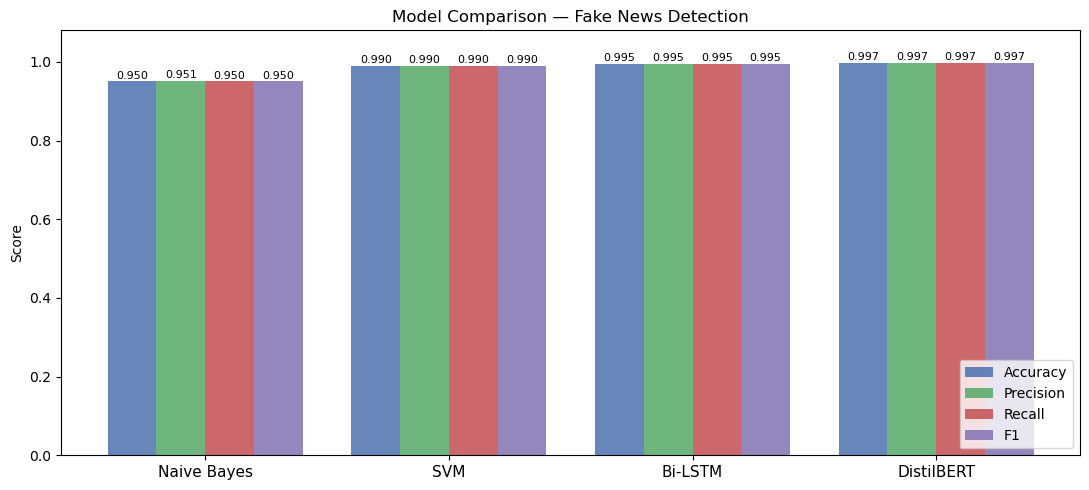

In [3]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
models       = results_df['Model'].tolist()
x            = np.arange(len(models))
width        = 0.2
colors       = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics_list, colors)):
    vals = results_df[metric].tolist()
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Fake News Detection')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150)
plt.show()


## 3 · Confusion Matrix Grid

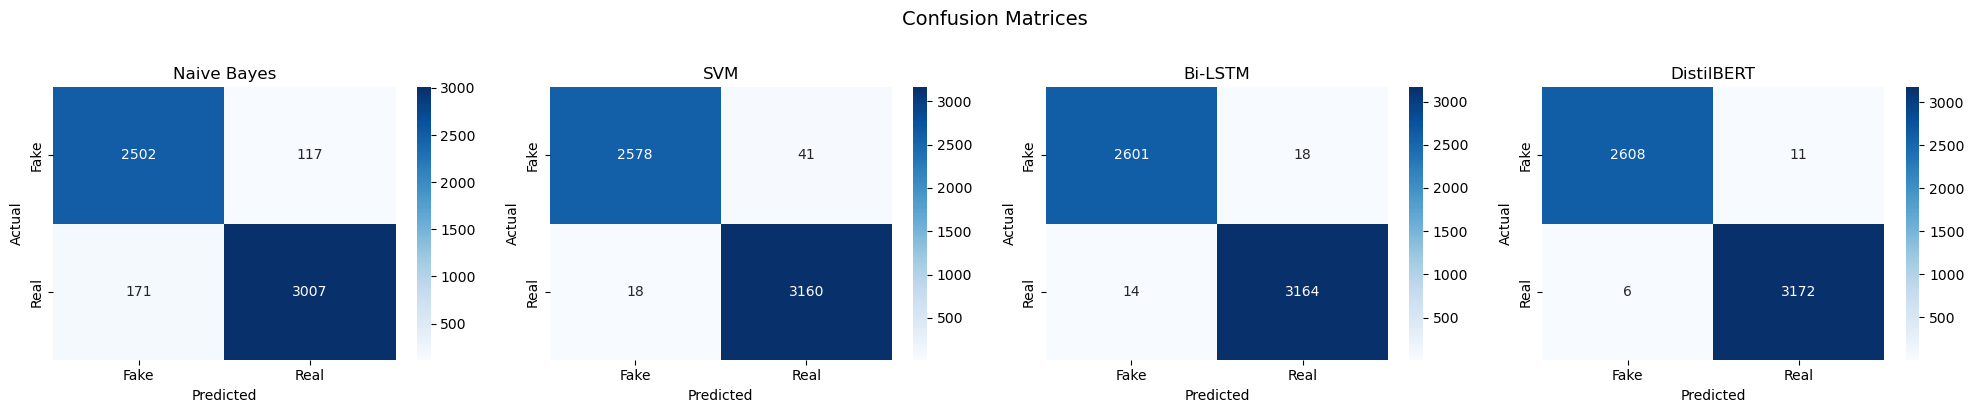

In [4]:
fig, axes = plt.subplots(1, len(preds), figsize=(5 * len(preds), 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()


## 4 · Per-class Performance Heatmaps
Shows Precision / Recall / F1 per class (Fake vs Real) for each model.

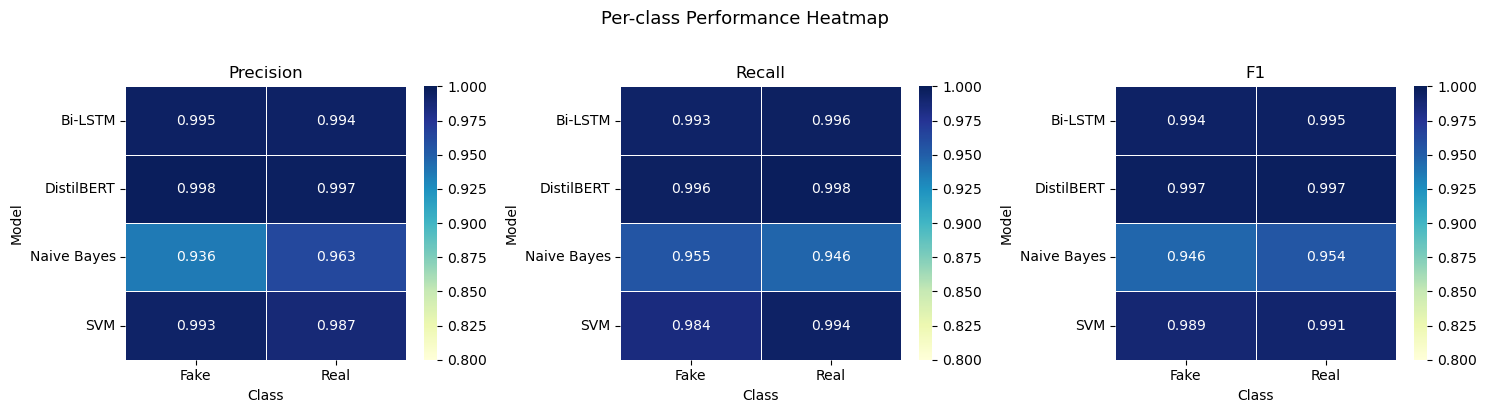

In [5]:
rows_pc = []
for model_name, y_pred in preds.items():
    for cls_idx, cls_name in enumerate(['Fake', 'Real']):
        mask = y_test == cls_idx
        # Evaluate only on samples of that class (recall = correct / total in class)
        rows_pc.append(dict(
            Model     = model_name,
            Class     = cls_name,
            Precision = precision_score(y_test, y_pred, labels=[cls_idx], average='macro', zero_division=0),
            Recall    = recall_score(y_test,    y_pred, labels=[cls_idx], average='macro', zero_division=0),
            F1        = f1_score(y_test,        y_pred, labels=[cls_idx], average='macro', zero_division=0),
        ))

per_class = pd.DataFrame(rows_pc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    pivot = per_class.pivot(index='Model', columns='Class', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                vmin=0.8, vmax=1.0, linewidths=0.5)
    ax.set_title(metric)
plt.suptitle('Per-class Performance Heatmap', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_heatmap.png'), dpi=150)
plt.show()


## 5 · Training Curves (DL Models)
Displays saved curve images — no re-training needed.

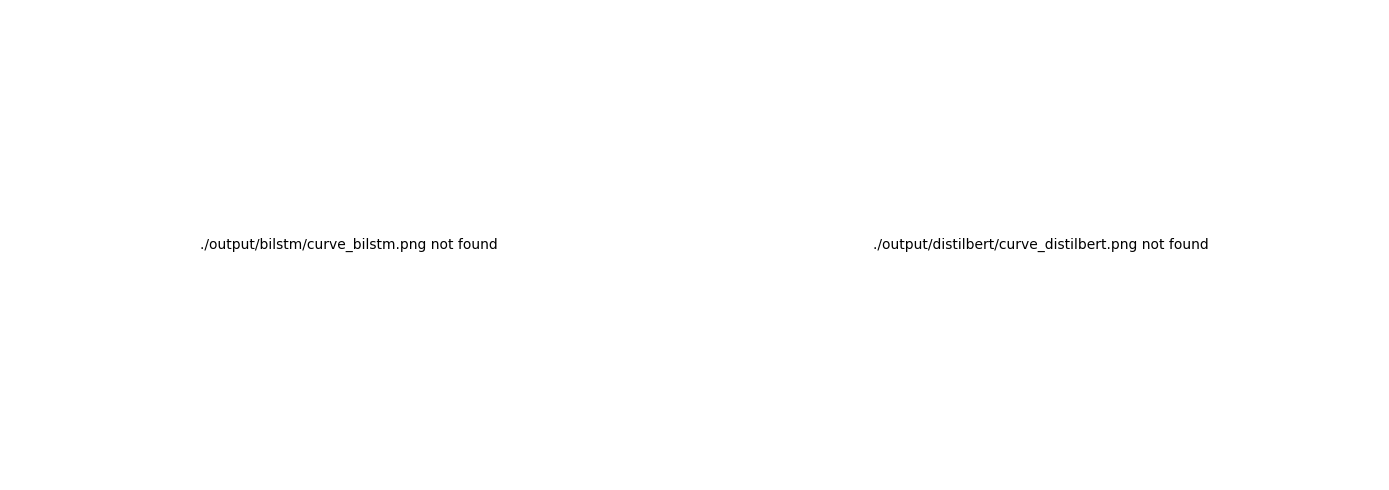

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, fname) in zip(axes, [
        ('Bi-LSTM Training Curve',     './output/bilstm/curve_bilstm.png'),
        ('DistilBERT Training Curve',  './output/distilbert/curve_distilbert.png'),
]):
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        img = plt.imread(path)
        ax.imshow(img); ax.axis('off'); ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f'{fname} not found', ha='center', va='center')
        ax.axis('off')
plt.tight_layout()
plt.show()


## 6 · Final Ranking

In [7]:
ranked = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
ranked.index += 1
ranked.index.name = 'Rank'
print('\n===== FINAL RANKING (by F1) =====')
print(ranked.to_string())
ranked.to_csv(os.path.join(OUTPUT_DIR, 'final_ranking.csv'))
print(f'\nSaved final_ranking.csv')



===== FINAL RANKING (by F1) =====
            Model  Accuracy  Precision  Recall      F1
Rank                                                  
1      DistilBERT    0.9971     0.9971  0.9971  0.9971
2         Bi-LSTM    0.9945     0.9945  0.9945  0.9945
3             SVM    0.9898     0.9898  0.9898  0.9898
4     Naive Bayes    0.9503     0.9506  0.9503  0.9504

Saved final_ranking.csv
